# Statistical MFCC Analysis of the FM ROI

This notebook loads the `97-99 MHz` region of interest (ROI) from each `data/acquisitions/Node*.csv` file, skips `Node9`, and overlays the **first ROI-intersecting acquisition** of the remaining sensors.

The MFCC statistical analysis is then built from **all ROI-intersecting acquisitions** of the kept sensors. The retained MFCC count is chosen automatically as the smallest number of coefficients whose `95%` confidence lower bound for cumulative cepstral energy reaches `95%`, and the notebook includes both the mean coefficient profile and a histogram view of the retained MFCC distributions **per sensor**.


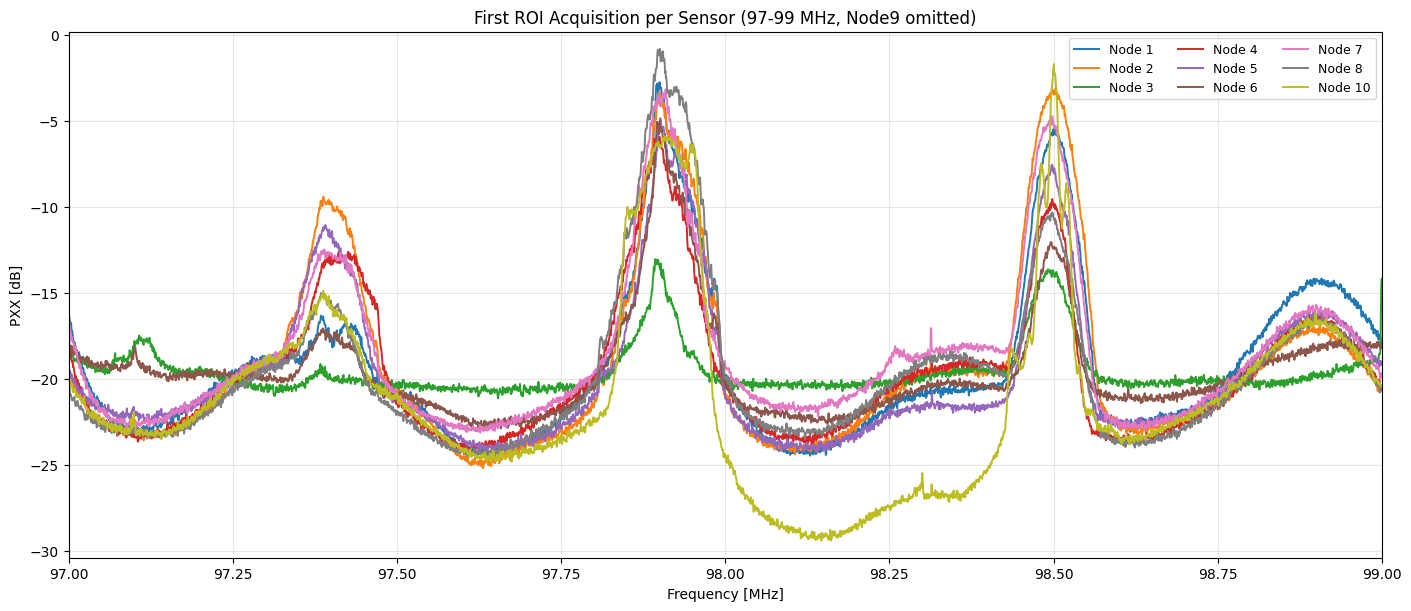

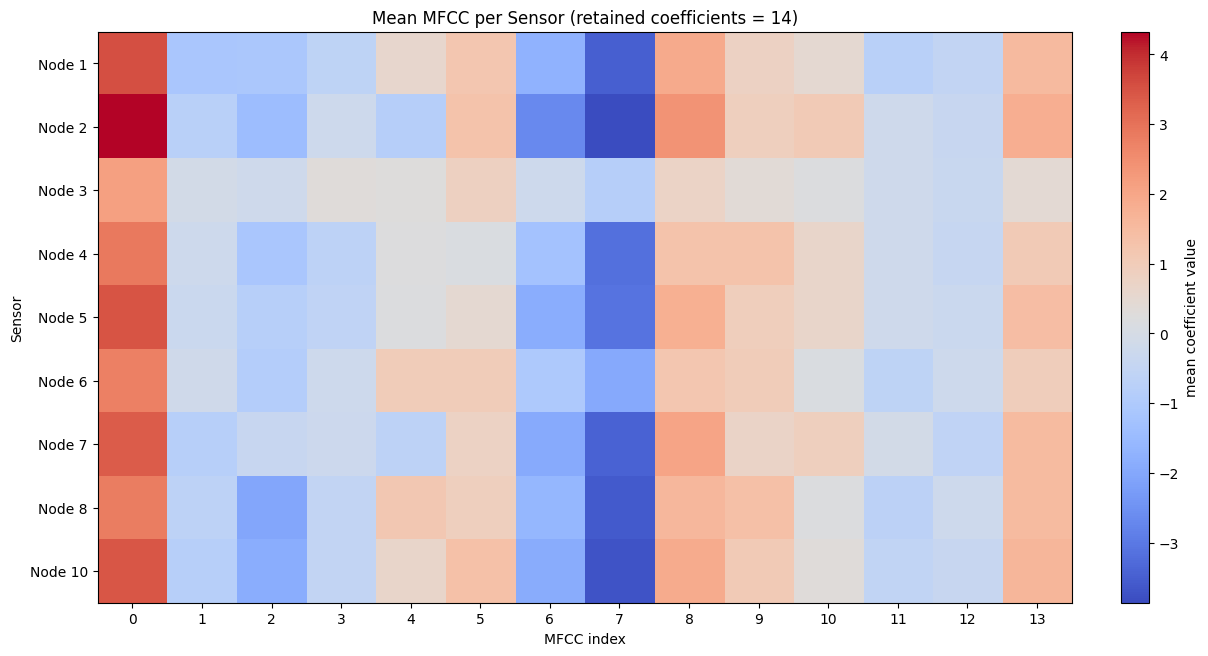

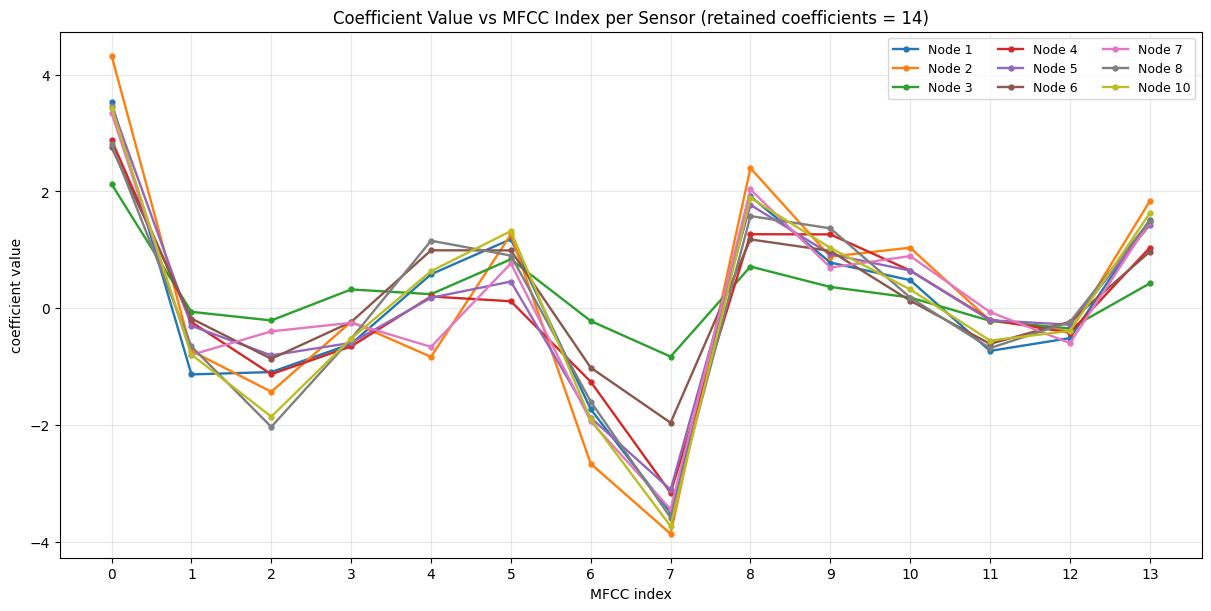

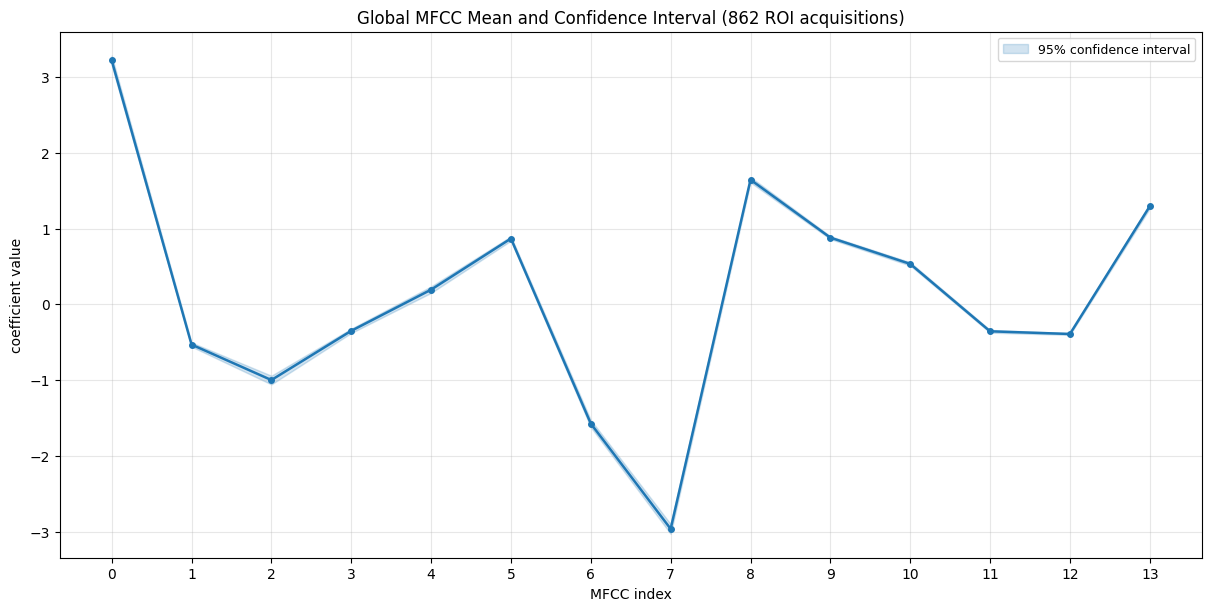

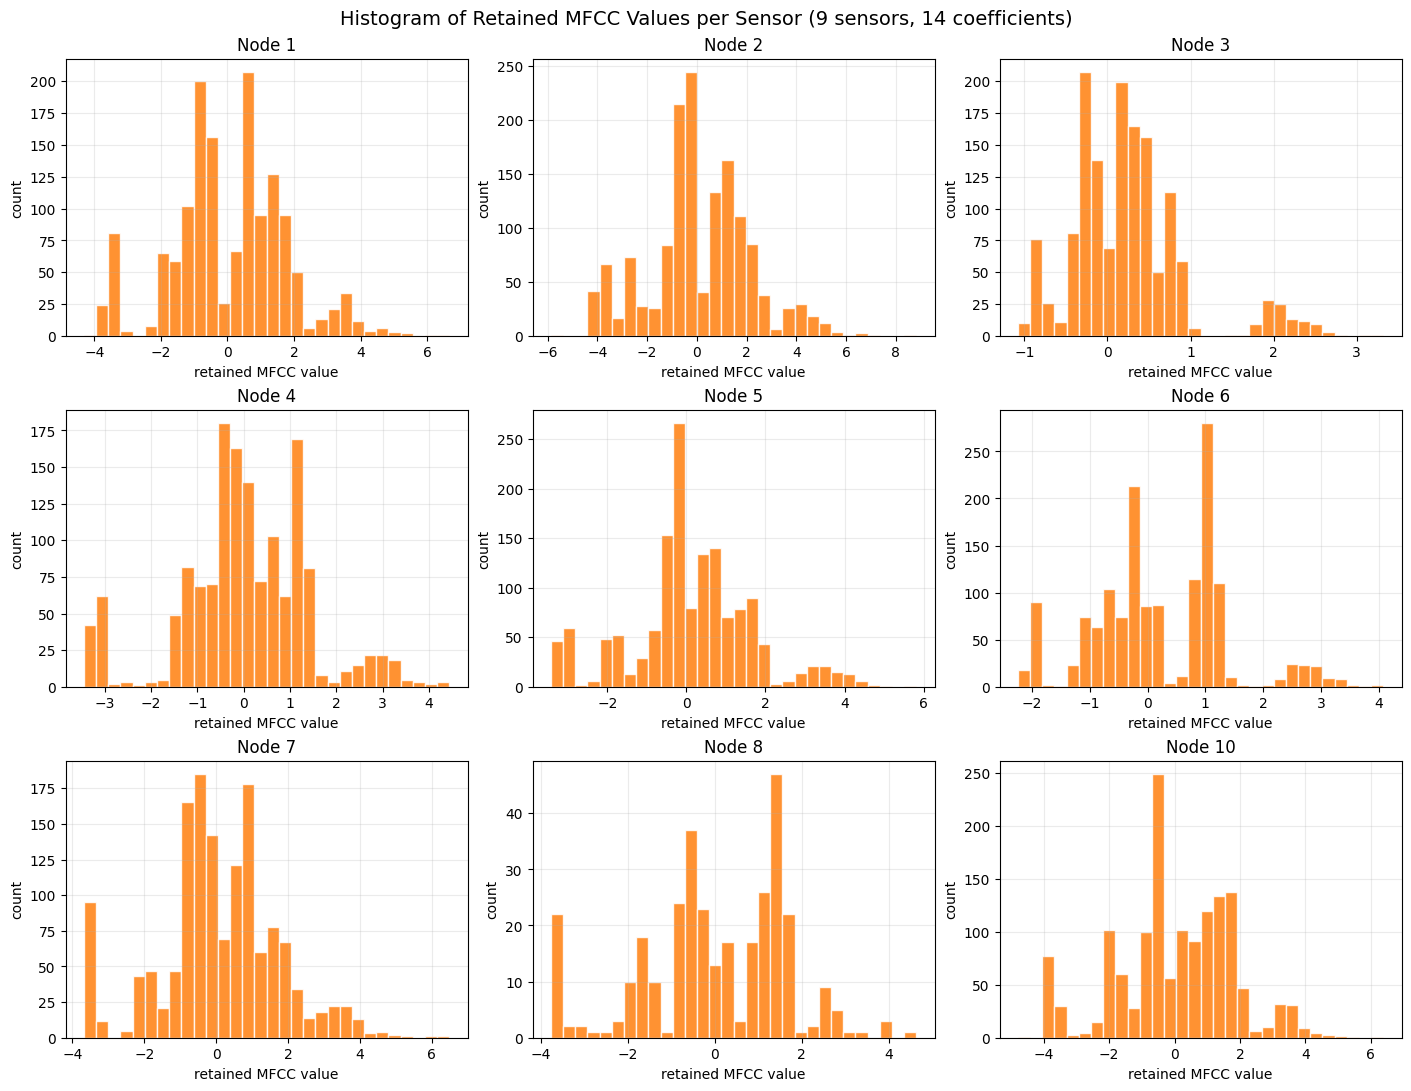

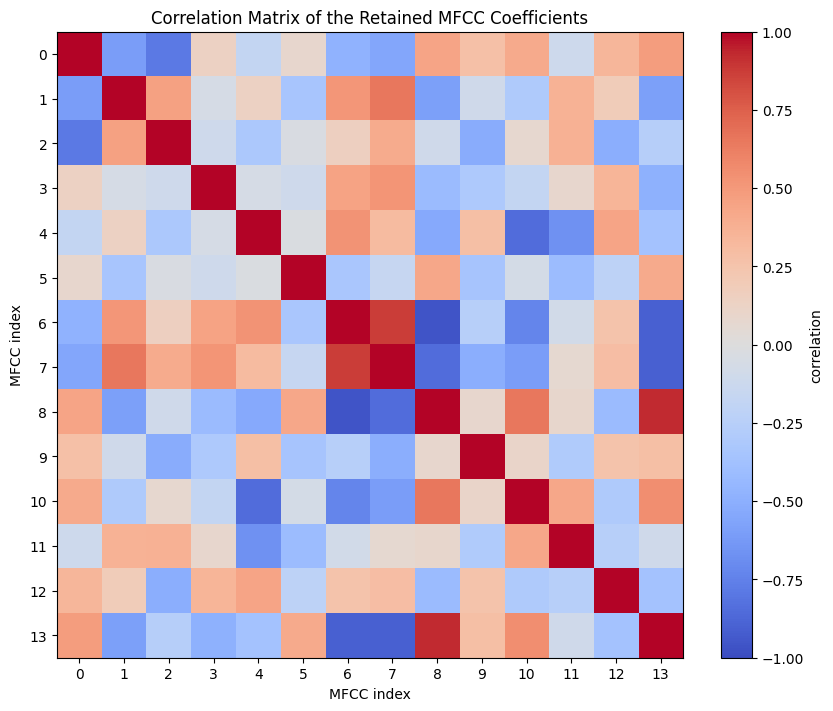

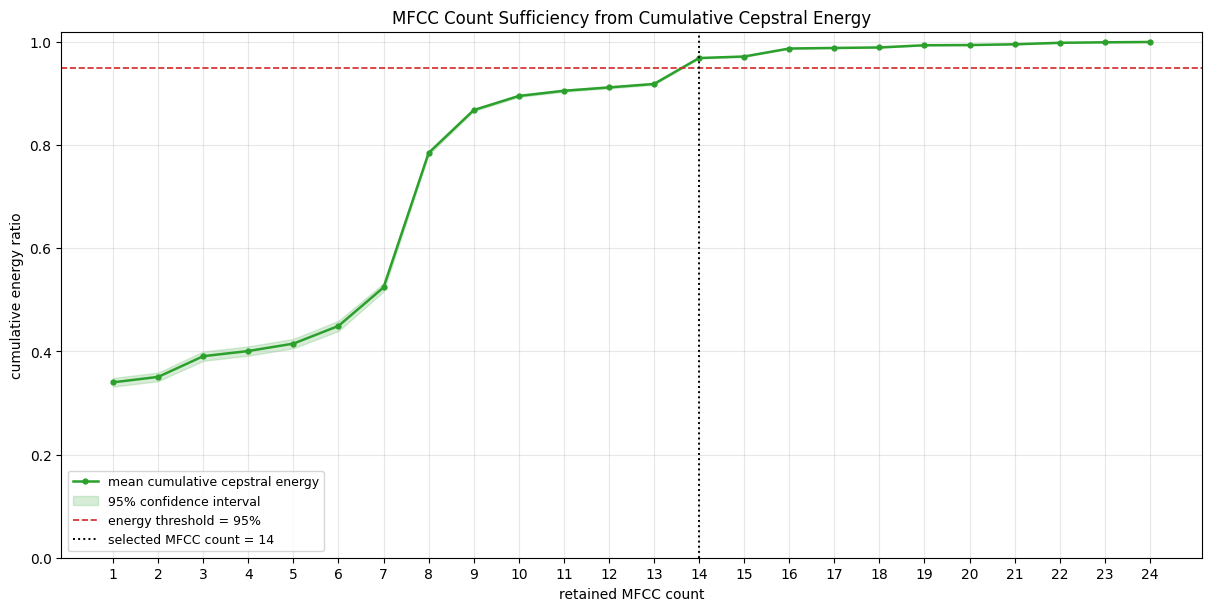

In [2]:
from __future__ import annotations

import csv
import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import dct
from scipy.stats import t

csv.field_size_limit(10**9)

ROI_START_MHZ = 97.0
ROI_END_MHZ = 99.0
SKIPPED_SENSOR_INDICES = frozenset({9})
NUM_MEL_BANDS = 24
ENERGY_CAPTURE_THRESHOLD = 0.95
CONFIDENCE_LEVEL = 0.95
MFCC_LOG_EPS = 1.0e-10


@dataclass(frozen=True)
class SensorRoiAcquisitionSeries:
    """All ROI-intersecting acquisitions loaded from one sensor CSV file.

    Attributes
    ----------
    sensor_index:
        Numeric sensor identifier extracted from the filename.
    location:
        Location label encoded in the filename.
    roi_frequency_hz:
        Shared frequency axis for the kept ROI samples [Hz].
    roi_traces_db:
        ROI traces with shape `(num_plotted_acquisitions, num_roi_bins)` in dB.
    total_acquisitions:
        Number of acquisitions available in the CSV file.
    plotted_acquisitions:
        Number of acquisitions whose band intersects the requested ROI.
    available_bands_mhz:
        Sorted list of unique acquisition bands observed in the file [MHz].
    """

    sensor_index: int
    location: str
    roi_frequency_hz: np.ndarray
    roi_traces_db: np.ndarray
    total_acquisitions: int
    plotted_acquisitions: int
    available_bands_mhz: tuple[tuple[float, float], ...]


@dataclass(frozen=True)
class RoiMfccObservation:
    """MFCC observation derived from one ROI-intersecting acquisition.

    Attributes
    ----------
    sensor_index:
        Numeric sensor identifier used to group repeated acquisitions.
    location:
        Location label encoded in the filename.
    acquisition_index:
        Zero-based index of the acquisition within the sensor CSV file.
    mel_log_energies:
        Log-mel energy vector computed from the ROI spectrum.
    full_cepstral_coefficients:
        Full DCT-II cepstral vector before truncation.
    """

    sensor_index: int
    location: str
    acquisition_index: int
    mel_log_energies: np.ndarray
    full_cepstral_coefficients: np.ndarray


@dataclass(frozen=True)
class MfccStatisticalSelection:
    """Statistical evidence used to choose a sufficient MFCC count.

    Attributes
    ----------
    selected_n_mfcc:
        Smallest MFCC count whose lower confidence bound reaches the target.
    mean_cumulative_energy_ratio:
        Mean retained cepstral energy ratio for each candidate coefficient count.
    lower_cumulative_energy_ratio:
        Lower confidence bound of the cumulative energy ratio.
    upper_cumulative_energy_ratio:
        Upper confidence bound of the cumulative energy ratio.
    confidence_level:
        Confidence level used for the interval construction.
    energy_capture_threshold:
        Target cumulative cepstral energy ratio used for selection.
    num_observations:
        Number of ROI acquisitions contributing to the statistical estimate.
    """

    selected_n_mfcc: int
    mean_cumulative_energy_ratio: np.ndarray
    lower_cumulative_energy_ratio: np.ndarray
    upper_cumulative_energy_ratio: np.ndarray
    confidence_level: float
    energy_capture_threshold: float
    num_observations: int


@dataclass(frozen=True)
class MfccGlobalStatistics:
    """Aggregate statistics of the retained MFCC coefficients.

    Attributes
    ----------
    coefficient_mean:
        Mean MFCC value for each retained coefficient across all acquisitions.
    coefficient_lower_ci:
        Lower confidence bound for each retained coefficient.
    coefficient_upper_ci:
        Upper confidence bound for each retained coefficient.
    coefficient_correlation:
        Correlation matrix of the retained MFCC coefficients.
    """

    coefficient_mean: np.ndarray
    coefficient_lower_ci: np.ndarray
    coefficient_upper_ci: np.ndarray
    coefficient_correlation: np.ndarray


def find_repository_root(start_dir: Path) -> Path:
    """Return the repository root by locating the acquisitions directory.

    Parameters
    ----------
    start_dir:
        Directory from which the upward search begins.

    Returns
    -------
    Path
        Repository root that contains `data/acquisitions`.

    Raises
    ------
    FileNotFoundError
        If the notebook is executed outside this repository tree.
    """

    for candidate in (start_dir, *start_dir.parents):
        if (candidate / "data" / "acquisitions").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root containing data/acquisitions."
    )


def extract_sensor_index(csv_path: Path) -> int:
    """Extract the numeric sensor index from a file named like `Node10-Bogota.csv`."""

    match = re.match(r"Node(\d+)-", csv_path.stem)
    if match is None:
        raise ValueError(f"Unexpected sensor filename: {csv_path.name}")

    return int(match.group(1))


def build_frequency_axis_hz(
    start_freq_hz: float,
    end_freq_hz: float,
    num_points: int,
) -> np.ndarray:
    """Build the uniform frequency axis for one acquisition.

    The spectrum bins are assumed to cover the half-open interval
    `[start_freq_hz, end_freq_hz)` with constant spacing.

    Parameters
    ----------
    start_freq_hz:
        Lower edge of the measured frequency range [Hz].
    end_freq_hz:
        Upper edge of the measured frequency range [Hz].
    num_points:
        Number of spectral samples stored in each `pxx` trace.

    Returns
    -------
    np.ndarray
        Frequency axis with one value per spectral sample.

    Raises
    ------
    ValueError
        If the provided range or sample count is invalid.
    """

    if num_points <= 0:
        raise ValueError("num_points must be strictly positive.")
    if not np.isfinite(start_freq_hz) or not np.isfinite(end_freq_hz):
        raise ValueError("Frequency bounds must be finite numeric values.")
    if end_freq_hz <= start_freq_hz:
        raise ValueError("end_freq_hz must be strictly larger than start_freq_hz.")

    return np.linspace(start_freq_hz, end_freq_hz, num_points, endpoint=False)


def parse_pxx_trace(pxx_literal: str, csv_name: str) -> np.ndarray:
    """Parse one serialized `pxx` field into a validated 1D float32 array.

    Parameters
    ----------
    pxx_literal:
        Serialized Python-style list stored in the CSV file.
    csv_name:
        CSV filename used to produce actionable validation errors.

    Returns
    -------
    np.ndarray
        One-dimensional spectral trace in dB.

    Raises
    ------
    ValueError
        If the trace cannot be parsed or contains invalid numeric values.
    """

    try:
        pxx_db = np.fromstring(pxx_literal.strip()[1:-1], sep=",", dtype=np.float32)
    except ValueError as exc:
        raise ValueError(f"Could not parse the pxx array from {csv_name}.") from exc

    if pxx_db.ndim != 1 or pxx_db.size == 0:
        raise ValueError(f"The pxx array in {csv_name} must be a non-empty 1D array.")
    if not np.isfinite(pxx_db).all():
        raise ValueError(f"The pxx array in {csv_name} contains NaN or Inf values.")

    return pxx_db


def load_roi_acquisitions(
    csv_path: Path,
    roi_start_mhz: float,
    roi_end_mhz: float,
) -> SensorRoiAcquisitionSeries:
    """Load only the acquisitions that intersect the requested ROI.

    Parameters
    ----------
    csv_path:
        Path to a sensor acquisition CSV file.
    roi_start_mhz:
        Lower ROI limit for the x-axis [MHz].
    roi_end_mhz:
        Upper ROI limit for the x-axis [MHz].

    Returns
    -------
    SensorRoiAcquisitionSeries
        ROI-only traces for the requested sensor.

    Raises
    ------
    ValueError
        If the CSV is empty, if the ROI is invalid, or if the intersecting
        acquisitions do not share the same ROI grid.
    """

    if roi_end_mhz <= roi_start_mhz:
        raise ValueError("roi_end_mhz must be strictly larger than roi_start_mhz.")

    with csv_path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))

    if not rows:
        raise ValueError(f"The file {csv_path.name} does not contain acquisitions.")

    roi_start_hz = roi_start_mhz * 1e6
    roi_end_hz = roi_end_mhz * 1e6

    roi_frequency_hz: np.ndarray | None = None
    roi_traces_db: list[np.ndarray] = []
    available_bands_hz: set[tuple[float, float]] = set()

    # Extract the ROI per acquisition because some files mix acquisition bands.
    for row in rows:
        try:
            start_freq_hz = float(row["start_freq_hz"])
            end_freq_hz = float(row["end_freq_hz"])
        except (KeyError, TypeError, ValueError) as exc:
            raise ValueError(f"Malformed frequency metadata in {csv_path.name}.") from exc

        available_bands_hz.add((start_freq_hz, end_freq_hz))

        pxx_db = parse_pxx_trace(row["pxx"], csv_path.name)
        frequency_hz = build_frequency_axis_hz(
            start_freq_hz=start_freq_hz,
            end_freq_hz=end_freq_hz,
            num_points=pxx_db.size,
        )
        roi_mask = (frequency_hz >= roi_start_hz) & (frequency_hz <= roi_end_hz)

        if not np.any(roi_mask):
            continue

        candidate_roi_frequency_hz = frequency_hz[roi_mask]
        candidate_roi_trace_db = pxx_db[roi_mask]

        if roi_frequency_hz is None:
            roi_frequency_hz = candidate_roi_frequency_hz
        elif not np.allclose(roi_frequency_hz, candidate_roi_frequency_hz):
            raise ValueError(
                f"Inconsistent ROI grid detected across acquisitions in {csv_path.name}."
            )

        roi_traces_db.append(candidate_roi_trace_db)

    location_parts = csv_path.stem.split("-", maxsplit=1)
    if len(location_parts) != 2:
        raise ValueError(f"Could not extract the location from {csv_path.name}.")

    if roi_frequency_hz is None:
        roi_frequency_hz = np.empty(0, dtype=np.float64)

    if roi_traces_db:
        roi_traces_array = np.vstack(roi_traces_db)
    else:
        roi_traces_array = np.empty((0, roi_frequency_hz.size), dtype=np.float32)

    available_bands_mhz = tuple(
        sorted((start_hz / 1e6, end_hz / 1e6) for start_hz, end_hz in available_bands_hz)
    )

    return SensorRoiAcquisitionSeries(
        sensor_index=extract_sensor_index(csv_path),
        location=location_parts[1],
        roi_frequency_hz=roi_frequency_hz,
        roi_traces_db=roi_traces_array,
        total_acquisitions=len(rows),
        plotted_acquisitions=roi_traces_array.shape[0],
        available_bands_mhz=available_bands_mhz,
    )


def hz_to_mel(frequency_hz: np.ndarray) -> np.ndarray:
    """Map Hertz frequencies to mel frequencies using the HTK formula."""

    frequency_hz = np.asarray(frequency_hz, dtype=np.float64)
    return 2595.0 * np.log10(1.0 + (frequency_hz / 700.0))


def mel_to_hz(mel_values: np.ndarray) -> np.ndarray:
    """Map mel frequencies back to Hertz using the inverse HTK formula."""

    mel_values = np.asarray(mel_values, dtype=np.float64)
    return 700.0 * (10.0 ** (mel_values / 2595.0) - 1.0)


def build_mel_filterbank_for_frequency_axis(
    frequency_hz: np.ndarray,
    n_mels: int,
) -> np.ndarray:
    """Create a triangular mel filterbank directly on the ROI frequency axis.

    Parameters
    ----------
    frequency_hz:
        Monotonically increasing ROI frequency axis [Hz].
    n_mels:
        Number of mel filters spanning the ROI band.

    Returns
    -------
    np.ndarray
        Triangular filterbank with shape `(n_mels, num_roi_bins)`.

    Raises
    ------
    ValueError
        If the axis is invalid or if the mel filters cannot be constructed.
    """

    frequency_hz = np.asarray(frequency_hz, dtype=np.float64)

    if frequency_hz.ndim != 1 or frequency_hz.size < 3:
        raise ValueError("frequency_hz must be a one-dimensional array with at least 3 bins.")
    if n_mels <= 0:
        raise ValueError("n_mels must be strictly positive.")
    if not np.all(np.isfinite(frequency_hz)):
        raise ValueError("frequency_hz contains NaN or Inf values.")
    if not np.all(np.diff(frequency_hz) > 0.0):
        raise ValueError("frequency_hz must be strictly increasing.")

    mel_edges = np.linspace(
        hz_to_mel(np.array([frequency_hz[0]], dtype=np.float64))[0],
        hz_to_mel(np.array([frequency_hz[-1]], dtype=np.float64))[0],
        n_mels + 2,
    )
    hz_edges = mel_to_hz(mel_edges)

    filterbank = np.zeros((n_mels, frequency_hz.size), dtype=np.float32)

    # Build each triangular mel band directly from the physical ROI frequency axis.
    for mel_index in range(n_mels):
        left_hz = float(hz_edges[mel_index])
        center_hz = float(hz_edges[mel_index + 1])
        right_hz = float(hz_edges[mel_index + 2])

        if not (left_hz < center_hz < right_hz):
            raise ValueError("Mel filter edges must be strictly increasing.")

        rising_mask = (frequency_hz >= left_hz) & (frequency_hz <= center_hz)
        falling_mask = (frequency_hz >= center_hz) & (frequency_hz <= right_hz)

        filterbank[mel_index, rising_mask] = (
            (frequency_hz[rising_mask] - left_hz) / (center_hz - left_hz)
        ).astype(np.float32, copy=False)
        filterbank[mel_index, falling_mask] = (
            (right_hz - frequency_hz[falling_mask]) / (right_hz - center_hz)
        ).astype(np.float32, copy=False)

    if np.any(filterbank.sum(axis=1) <= 0.0):
        raise ValueError("At least one mel filter is empty for the provided ROI axis.")

    return filterbank


def compute_roi_mel_log_energies(
    roi_trace_db: np.ndarray,
    mel_filterbank: np.ndarray,
    eps: float,
) -> np.ndarray:
    """Project one ROI spectrum onto mel bands and return log-mel energies.

    Parameters
    ----------
    roi_trace_db:
        ROI power-spectrum trace expressed in dB.
    mel_filterbank:
        Triangular mel projection matrix with one row per mel band.
    eps:
        Strictly positive floor applied before the logarithm.

    Returns
    -------
    np.ndarray
        One-dimensional log-mel energy vector.

    Raises
    ------
    ValueError
        If the spectrum, filterbank, or numerical floor is invalid.
    """

    roi_trace_db = np.asarray(roi_trace_db, dtype=np.float64)
    mel_filterbank = np.asarray(mel_filterbank, dtype=np.float64)

    if roi_trace_db.ndim != 1:
        raise ValueError("roi_trace_db must be one-dimensional.")
    if mel_filterbank.ndim != 2:
        raise ValueError("mel_filterbank must be two-dimensional.")
    if mel_filterbank.shape[1] != roi_trace_db.size:
        raise ValueError("mel_filterbank width must match roi_trace_db length.")
    if eps <= 0.0:
        raise ValueError("eps must be strictly positive.")
    if not np.all(np.isfinite(roi_trace_db)):
        raise ValueError("roi_trace_db contains NaN or Inf values.")

    # Convert dB power density back to linear power before mel-band accumulation.
    linear_power = 10.0 ** (roi_trace_db / 10.0)
    mel_power = mel_filterbank @ linear_power
    return np.log(np.maximum(mel_power, eps)).astype(np.float32, copy=False)


def build_roi_mfcc_observations(
    acquisition_series: list[SensorRoiAcquisitionSeries],
    n_mels: int,
    eps: float,
) -> list[RoiMfccObservation]:
    """Build MFCC observations from every ROI-intersecting acquisition.

    Parameters
    ----------
    acquisition_series:
        ROI traces grouped by sensor.
    n_mels:
        Number of mel filters used for every acquisition.
    eps:
        Strictly positive floor applied before logarithmic compression.

    Returns
    -------
    list[RoiMfccObservation]
        One MFCC observation per ROI-intersecting acquisition.

    Raises
    ------
    ValueError
        If no ROI acquisition is available to build the statistical dataset.
    """

    observations: list[RoiMfccObservation] = []

    # Reuse one filterbank per sensor because all its ROI traces share the same axis.
    for series in acquisition_series:
        if series.plotted_acquisitions == 0:
            continue

        mel_filterbank = build_mel_filterbank_for_frequency_axis(
            frequency_hz=series.roi_frequency_hz,
            n_mels=n_mels,
        )

        for acquisition_index, roi_trace_db in enumerate(series.roi_traces_db):
            mel_log_energies = compute_roi_mel_log_energies(
                roi_trace_db=roi_trace_db,
                mel_filterbank=mel_filterbank,
                eps=eps,
            )
            full_cepstral_coefficients = dct(
                mel_log_energies,
                type=2,
                norm="ortho",
            ).astype(np.float32, copy=False)
            observations.append(
                RoiMfccObservation(
                    sensor_index=series.sensor_index,
                    location=series.location,
                    acquisition_index=acquisition_index,
                    mel_log_energies=mel_log_energies,
                    full_cepstral_coefficients=full_cepstral_coefficients,
                )
            )

    if not observations:
        raise ValueError("No ROI acquisition is available for MFCC analysis.")

    return observations


def compute_confidence_interval(
    sample_matrix: np.ndarray,
    confidence_level: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute column-wise mean and Student-t confidence intervals.

    Parameters
    ----------
    sample_matrix:
        Two-dimensional sample matrix with observations on rows.
    confidence_level:
        Confidence level in the open interval `(0, 1)`.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray]
        `(mean, lower_ci, upper_ci)` computed column-wise.

    Raises
    ------
    ValueError
        If the matrix shape or confidence level is invalid.
    """

    sample_matrix = np.asarray(sample_matrix, dtype=np.float64)

    if sample_matrix.ndim != 2 or sample_matrix.shape[0] == 0:
        raise ValueError("sample_matrix must be two-dimensional with at least one row.")
    if not (0.0 < confidence_level < 1.0):
        raise ValueError("confidence_level must satisfy 0 < confidence_level < 1.")
    if not np.all(np.isfinite(sample_matrix)):
        raise ValueError("sample_matrix contains NaN or Inf values.")

    sample_mean = sample_matrix.mean(axis=0)
    if sample_matrix.shape[0] == 1:
        return (
            sample_mean.astype(np.float32, copy=False),
            sample_mean.astype(np.float32, copy=False),
            sample_mean.astype(np.float32, copy=False),
        )

    sample_std = sample_matrix.std(axis=0, ddof=1)
    sample_sem = sample_std / np.sqrt(float(sample_matrix.shape[0]))
    t_critical = float(t.ppf(0.5 + confidence_level / 2.0, df=sample_matrix.shape[0] - 1))
    half_width = t_critical * sample_sem

    return (
        sample_mean.astype(np.float32, copy=False),
        (sample_mean - half_width).astype(np.float32, copy=False),
        (sample_mean + half_width).astype(np.float32, copy=False),
    )


def select_statistically_sufficient_mfcc_count(
    mfcc_observations: list[RoiMfccObservation],
    energy_capture_threshold: float,
    confidence_level: float,
) -> MfccStatisticalSelection:
    """Choose the smallest MFCC count that is statistically sufficient.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    energy_capture_threshold:
        Target cumulative cepstral energy ratio.
    confidence_level:
        Confidence level used for the lower-bound test.

    Returns
    -------
    MfccStatisticalSelection
        Statistical evidence and the selected MFCC count.

    Raises
    ------
    ValueError
        If the threshold, confidence level, or observation list is invalid.
    """

    if not mfcc_observations:
        raise ValueError("At least one MFCC observation is required for selection.")
    if not (0.0 < energy_capture_threshold < 1.0):
        raise ValueError("energy_capture_threshold must satisfy 0 < threshold < 1.")
    if not (0.0 < confidence_level < 1.0):
        raise ValueError("confidence_level must satisfy 0 < confidence_level < 1.")

    full_cepstral_matrix = np.vstack(
        [observation.full_cepstral_coefficients for observation in mfcc_observations]
    ).astype(np.float64, copy=False)
    cepstral_energy = full_cepstral_matrix ** 2
    total_energy = np.sum(cepstral_energy, axis=1, keepdims=True)

    if np.any(total_energy <= 0.0):
        raise ValueError("Every MFCC observation must contain strictly positive cepstral energy.")

    cumulative_energy_ratio = np.cumsum(cepstral_energy, axis=1) / total_energy
    mean_ratio, lower_ratio, upper_ratio = compute_confidence_interval(
        sample_matrix=cumulative_energy_ratio,
        confidence_level=confidence_level,
    )
    lower_ratio = np.clip(lower_ratio, 0.0, 1.0)
    upper_ratio = np.clip(upper_ratio, 0.0, 1.0)

    satisfying_indices = np.flatnonzero(lower_ratio >= energy_capture_threshold)
    selected_n_mfcc = int(satisfying_indices[0] + 1) if satisfying_indices.size > 0 else int(lower_ratio.size)

    return MfccStatisticalSelection(
        selected_n_mfcc=selected_n_mfcc,
        mean_cumulative_energy_ratio=mean_ratio,
        lower_cumulative_energy_ratio=lower_ratio,
        upper_cumulative_energy_ratio=upper_ratio,
        confidence_level=confidence_level,
        energy_capture_threshold=energy_capture_threshold,
        num_observations=len(mfcc_observations),
    )


def extract_retained_mfcc_matrix(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> np.ndarray:
    """Extract the retained MFCC matrix with observations on rows.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of retained coefficients.

    Returns
    -------
    np.ndarray
        Matrix with shape `(num_observations, selected_n_mfcc)`.

    Raises
    ------
    ValueError
        If no observation is available or if the retained count is invalid.
    """

    if not mfcc_observations:
        raise ValueError("At least one MFCC observation is required.")

    full_cepstral_matrix = np.vstack(
        [observation.full_cepstral_coefficients for observation in mfcc_observations]
    ).astype(np.float32, copy=False)

    if not (1 <= selected_n_mfcc <= full_cepstral_matrix.shape[1]):
        raise ValueError("selected_n_mfcc must lie within the available cepstral dimension.")

    return full_cepstral_matrix[:, :selected_n_mfcc]


def compute_global_mfcc_statistics(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
    confidence_level: float,
) -> MfccGlobalStatistics:
    """Compute aggregate statistics for the retained MFCC coefficients.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of coefficients retained for the statistical analysis.
    confidence_level:
        Confidence level used for the coefficient intervals.

    Returns
    -------
    MfccGlobalStatistics
        Mean, confidence intervals, and correlation matrix for the retained MFCCs.

    Raises
    ------
    ValueError
        If the retained coefficient count is invalid.
    """

    retained_matrix = extract_retained_mfcc_matrix(
        mfcc_observations=mfcc_observations,
        selected_n_mfcc=selected_n_mfcc,
    ).astype(np.float64, copy=False)
    coefficient_mean, coefficient_lower_ci, coefficient_upper_ci = compute_confidence_interval(
        sample_matrix=retained_matrix,
        confidence_level=confidence_level,
    )

    if selected_n_mfcc == 1:
        coefficient_correlation = np.ones((1, 1), dtype=np.float32)
    else:
        coefficient_correlation = np.corrcoef(retained_matrix, rowvar=False).astype(np.float32, copy=False)
        coefficient_correlation = np.nan_to_num(coefficient_correlation, nan=0.0)
        np.fill_diagonal(coefficient_correlation, 1.0)

    return MfccGlobalStatistics(
        coefficient_mean=coefficient_mean,
        coefficient_lower_ci=coefficient_lower_ci,
        coefficient_upper_ci=coefficient_upper_ci,
        coefficient_correlation=coefficient_correlation,
    )


def build_sensor_mean_mfcc_matrix(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> tuple[list[str], np.ndarray]:
    """Aggregate the retained MFCC coefficients into one mean profile per sensor.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of coefficients retained for the analysis.

    Returns
    -------
    tuple[list[str], np.ndarray]
        Sensor labels and mean MFCC matrix with shape `(num_sensors, selected_n_mfcc)`.
    """

    grouped_coefficients: dict[int, list[np.ndarray]] = {}
    for observation in mfcc_observations:
        grouped_coefficients.setdefault(observation.sensor_index, []).append(
            observation.full_cepstral_coefficients[:selected_n_mfcc]
        )

    ordered_sensor_indices = sorted(grouped_coefficients)
    sensor_labels = [f"Node {sensor_index}" for sensor_index in ordered_sensor_indices]
    sensor_mean_matrix = np.vstack(
        [
            np.vstack(grouped_coefficients[sensor_index]).mean(axis=0)
            for sensor_index in ordered_sensor_indices
        ]
    ).astype(np.float32, copy=False)

    return sensor_labels, sensor_mean_matrix


def plot_first_roi_acquisition_overlay(
    acquisition_series: list[SensorRoiAcquisitionSeries],
    roi_start_mhz: float,
    roi_end_mhz: float,
) -> None:
    """Plot the first ROI-intersecting acquisition of every kept sensor.

    Parameters
    ----------
    acquisition_series:
        ROI traces grouped by sensor.
    roi_start_mhz:
        Lower ROI limit [MHz].
    roi_end_mhz:
        Upper ROI limit [MHz].

    Returns
    -------
    None
        The function renders one matplotlib figure.
    """

    figure, axis = plt.subplots(figsize=(14, 6), constrained_layout=True)
    plotted_traces: list[np.ndarray] = []

    # Overlay the first valid ROI spectrum of each kept sensor with compact labels only.
    for series in acquisition_series:
        if series.plotted_acquisitions == 0:
            continue

        first_roi_trace_db = series.roi_traces_db[0]
        plotted_traces.append(first_roi_trace_db)
        axis.plot(
            series.roi_frequency_hz / 1e6,
            first_roi_trace_db,
            linewidth=1.4,
            label=f"Node {series.sensor_index}",
        )

    if not plotted_traces:
        raise ValueError("No first ROI acquisition is available for plotting.")

    axis.set_title(
        f"First ROI Acquisition per Sensor ({roi_start_mhz:.0f}-{roi_end_mhz:.0f} MHz, Node9 omitted)"
    )
    axis.set_xlabel("Frequency [MHz]")
    axis.set_ylabel("PXX [dB]")
    axis.set_xlim(roi_start_mhz, roi_end_mhz)
    axis.set_ylim(
        min(float(trace.min()) for trace in plotted_traces) - 1.0,
        max(float(trace.max()) for trace in plotted_traces) + 1.0,
    )
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=9)
    plt.show()


def plot_sensor_mean_mfcc_heatmap(
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    selected_n_mfcc: int,
) -> None:
    """Plot one heatmap of mean retained MFCC coefficients per sensor."""

    figure, axis = plt.subplots(
        figsize=(12, max(4.5, 0.55 * len(sensor_labels) + 1.5)),
        constrained_layout=True,
    )
    image = axis.imshow(sensor_mean_matrix, aspect="auto", origin="upper", cmap="coolwarm")
    axis.set_title(f"Mean MFCC per Sensor (retained coefficients = {selected_n_mfcc})")
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("Sensor")
    axis.set_yticks(np.arange(len(sensor_labels)), labels=sensor_labels)
    axis.set_xticks(np.arange(selected_n_mfcc))
    figure.colorbar(image, ax=axis, label="mean coefficient value")
    plt.show()


def plot_sensor_mean_mfcc_profiles(
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    selected_n_mfcc: int,
) -> None:
    """Plot the retained mean MFCC profile of each sensor against the MFCC index."""

    coefficient_indices = np.arange(selected_n_mfcc)
    figure, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)

    # Keep one profile per sensor so cross-node MFCC shape differences are easy to compare.
    for sensor_label, sensor_coefficients in zip(sensor_labels, sensor_mean_matrix):
        axis.plot(
            coefficient_indices,
            sensor_coefficients,
            linewidth=1.7,
            marker="o",
            markersize=3.5,
            label=sensor_label,
        )

    axis.set_title(f"Coefficient Value vs MFCC Index per Sensor (retained coefficients = {selected_n_mfcc})")
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("coefficient value")
    axis.set_xticks(coefficient_indices)
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=9)
    plt.show()


def plot_global_mfcc_statistics(
    mfcc_statistics: MfccGlobalStatistics,
    selection: MfccStatisticalSelection,
) -> None:
    """Plot the global MFCC mean profile with confidence intervals."""

    coefficient_indices = np.arange(selection.selected_n_mfcc)

    figure, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)
    axis.plot(
        coefficient_indices,
        mfcc_statistics.coefficient_mean,
        color="tab:blue",
        linewidth=1.8,
        marker="o",
        markersize=4.0,
    )
    axis.fill_between(
        coefficient_indices,
        mfcc_statistics.coefficient_lower_ci,
        mfcc_statistics.coefficient_upper_ci,
        color="tab:blue",
        alpha=0.20,
        label=f"{int(selection.confidence_level * 100)}% confidence interval",
    )
    axis.set_title(
        f"Global MFCC Mean and Confidence Interval ({selection.num_observations} ROI acquisitions)"
    )
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("coefficient value")
    axis.set_xticks(coefficient_indices)
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=9)
    plt.show()


def plot_mfcc_histograms(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> None:
    """Plot one histogram panel per sensor using the retained MFCC values.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of MFCC coefficients retained for the statistical analysis.
    """

    grouped_coefficients: dict[int, list[np.ndarray]] = {}
    for observation in mfcc_observations:
        grouped_coefficients.setdefault(observation.sensor_index, []).append(
            observation.full_cepstral_coefficients[:selected_n_mfcc]
        )

    ordered_sensor_indices = sorted(grouped_coefficients)
    num_sensors = len(ordered_sensor_indices)
    num_columns = 3
    num_rows = int(np.ceil(num_sensors / num_columns))
    figure, axes = plt.subplots(
        num_rows,
        num_columns,
        figsize=(14, max(7.0, 3.6 * num_rows)),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    # Flatten each sensor's retained MFCC samples so one panel summarizes its ROI coefficient distribution.
    for axis, sensor_index in zip(axes, ordered_sensor_indices):
        sensor_matrix = np.vstack(grouped_coefficients[sensor_index]).astype(np.float32, copy=False)
        flattened_sensor_coefficients = sensor_matrix.ravel()
        axis.hist(
            flattened_sensor_coefficients,
            bins=30,
            color="tab:orange",
            alpha=0.85,
            edgecolor="white",
        )
        axis.set_title(f"Node {sensor_index}")
        axis.set_xlabel("retained MFCC value")
        axis.set_ylabel("count")
        axis.grid(True, alpha=0.25)

    for axis in axes[num_sensors:]:
        axis.remove()

    figure.suptitle(
        f"Histogram of Retained MFCC Values per Sensor ({num_sensors} sensors, {selected_n_mfcc} coefficients)",
        fontsize=14,
    )
    plt.show()


def plot_mfcc_correlation_matrix(
    mfcc_statistics: MfccGlobalStatistics,
    selected_n_mfcc: int,
) -> None:
    """Plot the retained MFCC coefficient correlation matrix."""

    figure, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
    image = axis.imshow(
        mfcc_statistics.coefficient_correlation,
        vmin=-1.0,
        vmax=1.0,
        cmap="coolwarm",
        origin="upper",
    )
    coefficient_indices = np.arange(selected_n_mfcc)
    axis.set_title("Correlation Matrix of the Retained MFCC Coefficients")
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("MFCC index")
    axis.set_xticks(coefficient_indices)
    axis.set_yticks(coefficient_indices)
    figure.colorbar(image, ax=axis, label="correlation")
    plt.show()


def plot_mfcc_energy_sufficiency(selection: MfccStatisticalSelection) -> None:
    """Plot the cumulative cepstral-energy evidence used for MFCC selection."""

    coefficient_counts = np.arange(1, selection.mean_cumulative_energy_ratio.size + 1)

    figure, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)
    axis.plot(
        coefficient_counts,
        selection.mean_cumulative_energy_ratio,
        color="tab:green",
        linewidth=1.8,
        marker="o",
        markersize=3.5,
        label="mean cumulative cepstral energy",
    )
    axis.fill_between(
        coefficient_counts,
        selection.lower_cumulative_energy_ratio,
        selection.upper_cumulative_energy_ratio,
        color="tab:green",
        alpha=0.18,
        label=f"{int(selection.confidence_level * 100)}% confidence interval",
    )
    axis.axhline(
        selection.energy_capture_threshold,
        color="tab:red",
        linestyle="--",
        linewidth=1.2,
        label=f"energy threshold = {selection.energy_capture_threshold:.0%}",
    )
    axis.axvline(
        selection.selected_n_mfcc,
        color="black",
        linestyle=":",
        linewidth=1.4,
        label=f"selected MFCC count = {selection.selected_n_mfcc}",
    )
    axis.set_title(
        "MFCC Count Sufficiency from Cumulative Cepstral Energy"
    )
    axis.set_xlabel("retained MFCC count")
    axis.set_ylabel("cumulative energy ratio")
    axis.set_xticks(coefficient_counts)
    axis.set_ylim(0.0, 1.02)
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=9)
    plt.show()


# Resolve the data directory relative to the repository root, not to a fragile cwd assumption.
repository_root = find_repository_root(Path.cwd())
data_dir = repository_root / "data" / "acquisitions"

sensor_paths = [
    sensor_path
    for sensor_path in sorted(data_dir.glob("Node*.csv"), key=extract_sensor_index)
    if extract_sensor_index(sensor_path) not in SKIPPED_SENSOR_INDICES
]
if not sensor_paths:
    raise ValueError(f"No usable sensor files were found in {data_dir}.")

acquisition_series = [
    load_roi_acquisitions(
        csv_path=sensor_path,
        roi_start_mhz=ROI_START_MHZ,
        roi_end_mhz=ROI_END_MHZ,
    )
    for sensor_path in sensor_paths
]
mfcc_observations = build_roi_mfcc_observations(
    acquisition_series=acquisition_series,
    n_mels=NUM_MEL_BANDS,
    eps=MFCC_LOG_EPS,
)
mfcc_selection = select_statistically_sufficient_mfcc_count(
    mfcc_observations=mfcc_observations,
    energy_capture_threshold=ENERGY_CAPTURE_THRESHOLD,
    confidence_level=CONFIDENCE_LEVEL,
)
mfcc_statistics = compute_global_mfcc_statistics(
    mfcc_observations=mfcc_observations,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
    confidence_level=CONFIDENCE_LEVEL,
)
sensor_labels, sensor_mean_mfcc_matrix = build_sensor_mean_mfcc_matrix(
    mfcc_observations=mfcc_observations,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)

plot_first_roi_acquisition_overlay(
    acquisition_series=acquisition_series,
    roi_start_mhz=ROI_START_MHZ,
    roi_end_mhz=ROI_END_MHZ,
)
plot_sensor_mean_mfcc_heatmap(
    sensor_labels=sensor_labels,
    sensor_mean_matrix=sensor_mean_mfcc_matrix,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)
plot_sensor_mean_mfcc_profiles(
    sensor_labels=sensor_labels,
    sensor_mean_matrix=sensor_mean_mfcc_matrix,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)
plot_global_mfcc_statistics(
    mfcc_statistics=mfcc_statistics,
    selection=mfcc_selection,
)
plot_mfcc_histograms(
    mfcc_observations=mfcc_observations,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)
plot_mfcc_correlation_matrix(
    mfcc_statistics=mfcc_statistics,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)
plot_mfcc_energy_sufficiency(mfcc_selection)
